# Task 3

## Answer 3.a

The backtest compares the predicted 10-day 99% VaR on date $t$ with the forward 10-day log return.

Define the daily log return as
$$r_t = \ln\left(\frac{S_t}{S_{t-1}}\right)$$

Using the most recent 21 daily returns, the rolling volatility estimate is
$$\sigma_t = \operatorname{STDEV.S}(r_{t-20}, \ldots, r_t)$$

The predicted 10-day VaR is then
$$\mathrm{VaR}^{(10)}_t = \Phi^{-1}(0.01)\ * \sigma_t\ * \sqrt{10}$$

Tforward 10-day log return is computed as
$$r^{10D}_t = \ln\left(\frac{S_{t+10}}{S_{t}}\right)$$

A breach occurs whenever
$$r^{10D}_t < \mathrm{VaR}_t$$

The implementation is shown below.

First, import the required Python packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Define the relevant constants.

In [2]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: {inverse_cdf}')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


Load the index data from the Excel file.

In [3]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
data.index = pd.to_datetime(data.index)
data

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020
...,...,...
2026-01-26,6950.229980,25713.210938
2026-01-27,6978.600098,25939.740234
2026-01-28,6978.029785,26022.789062


Compute the 1D log-return.

In [4]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
data

,^GSPC,^NDX,LogReturn
Date,,,
2015-10-15,2023.859985,4418.220215,NaN
2015-10-16,2033.109985,4438.620117,0.004560
2015-10-19,2033.660034,4462.069824,0.000271
2015-10-20,2030.770020,4438.180176,-0.001422
2015-10-21,2018.939941,4413.520020,-0.005842
...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994
2026-01-27,6978.600098,25939.740234,0.004074
2026-01-28,6978.029785,26022.789062,-0.000082


Compute the forward 10-day log return.

In [5]:
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-10) / data['^GSPC'])
data

,^GSPC,^NDX,LogReturn,Forward10dReturn
Date,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875
2015-10-16,2033.109985,4438.620117,0.004560,0.022494
2015-10-19,2033.660034,4462.069824,0.000271,0.034027
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464
...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN
2026-01-27,6978.600098,25939.740234,0.004074,NaN
2026-01-28,6978.029785,26022.789062,-0.000082,NaN


Compute the 21D rolling standard deviation.

In [6]:
data['SD'] = data['LogReturn'].rolling(rolling_window, min_periods=rolling_window).std()
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD
Date,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875,NaN
2015-10-16,2033.109985,4438.620117,0.004560,0.022494,NaN
2015-10-19,2033.660034,4462.069824,0.000271,0.034027,NaN
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173,NaN
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464,NaN
...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642


Compute the 10-day VaR series and the breach indicator.

In [9]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)
data

,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2015-10-15,2023.859985,4418.220215,NaN,0.031875,NaN,NaN,0
2015-10-16,2033.109985,4438.620117,0.004560,0.022494,NaN,NaN,0
2015-10-19,2033.660034,4462.069824,0.000271,0.034027,NaN,NaN,0
2015-10-20,2030.770020,4438.180176,-0.001422,0.038173,NaN,NaN,0
2015-10-21,2018.939941,4413.520020,-0.005842,0.040464,NaN,NaN,0
...,...,...,...,...,...,...,...
2026-01-26,6950.229980,25713.210938,0.004994,NaN,0.006622,-0.048713,0
2026-01-27,6978.600098,25939.740234,0.004074,NaN,0.006643,-0.048872,0
2026-01-28,6978.029785,26022.789062,-0.000082,NaN,0.006642,-0.048865,0


Restrict the sample to the period from 2025-01-01 to 2026-01-15, and retain only observations for which both the VaR forecast and the realised forward 10-day return are available.

In [10]:
data = data.loc['2025-01-01':'2026-01-15'].copy()
backtest_data = data.dropna(subset=['VaR', 'Forward10dReturn']).copy()
total_count = backtest_data.shape[0]
print(f'Total count of observations: {total_count}')
backtest_data

Total count of observations: 260


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.021595,0.009015,-0.066318,0
2025-01-03,5942.470215,21326.160156,0.012517,0.017808,0.009511,-0.069972,0
2025-01-06,5975.379883,21559.500000,0.005523,0.018404,0.009494,-0.069840,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.034870,0.009755,-0.071766,0
2025-01-08,5918.250000,21180.970703,0.001559,0.030451,0.009739,-0.071647,0
...,...,...,...,...,...,...,...
2026-01-09,6966.279785,25766.259766,0.006455,-0.002307,0.005953,-0.043792,0
2026-01-12,6977.270020,25787.660156,0.001576,0.000191,0.005804,-0.042694,0
2026-01-13,6963.740234,25741.949219,-0.001941,0.002050,0.005819,-0.042811,0


Extract the rows corresponding to VaR breaches.

In [11]:
data_breach = backtest_data[backtest_data['Breach'] == 1]
breach_count = data_breach.shape[0]
print(f'Count of breaches: {breach_count}')
data_breach

Count of breaches: 10


,^GSPC,^NDX,LogReturn,Forward10dReturn,SD,VaR,Breach
Date,,,,,,,
2025-02-18,6129.580078,22164.609375,0.002442,-0.059043,0.006966,-0.051246,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.050319,0.006699,-0.049282,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.063955,0.006566,-0.048305,1
2025-02-24,5983.250000,21352.080078,-0.004981,-0.063601,0.007416,-0.054557,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.066507,0.007449,-0.054799,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.061768,0.006774,-0.049834,1
2025-02-27,5861.569824,20550.949219,-0.015992,-0.059764,0.007199,-0.052963,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.110613,0.012759,-0.093862,1
2025-03-24,5767.569824,20180.449219,0.017492,-0.130440,0.013154,-0.096770,1


In [12]:
print(f'Count of breaches: {breach_count}, total count: {total_count}, breach percentage: {breach_count/total_count*100:.2f}%')

Count of breaches: 10, total count: 260, breach percentage: 3.85%


Hence, the valid backtesting sample contains 10 VaR breaches, corresponding to 3.86% of the 259 valid observations.

---

## Answer 3.b

Two plots are shown below.

The first plot compares the predicted 10-day VaR with the realised forward 10-day return and highlights the breach observations with black crosses.

The second plot shows the S&P 500 index level over the same sample period.

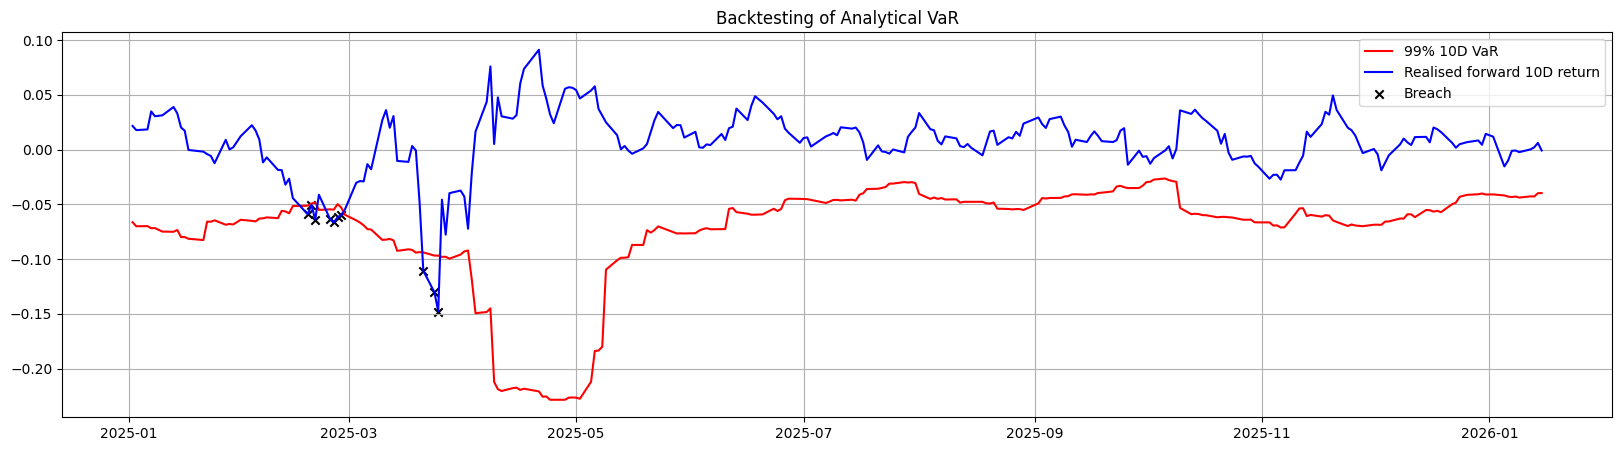

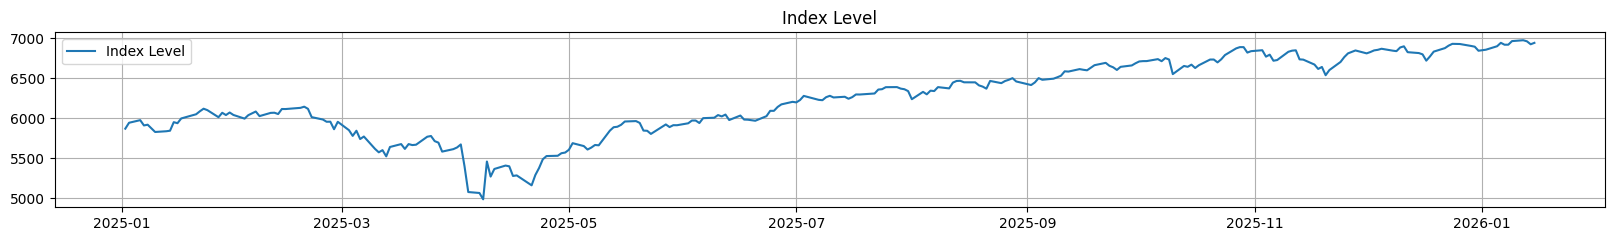

In [14]:
# Figure 1
plt.title('Backtesting of Analytical VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['Forward10dReturn'], color='BLACK', marker='x')
plt.legend(["99% 10D VaR", "Realised forward 10D return", "Breach"])
plt.grid()

# Figure 2
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

---

### Answer 3.c

Using the binomial distribution $B \sim \mathrm{Binomial}(T, 0.01)$, where $T = 260$ is the number of valid backtesting observations:

- Green zone: $0 \leq b \leq q_{0.95}$
- Yellow zone: $q_{0.95} < b \leq q_{0.9999}$
- Red zone: $b > q_{0.9999}$

Since the observed breach count is 10, the model falls within the **yellow** zone.

In [15]:
from scipy.stats import binom
q_green = binom.ppf(0.95, total_count, 0.01)
q_yellow = binom.ppf(0.9999, total_count, 0.01)
print(f'Green zone: [0 to {q_green:.0f}] breaches')
print(f'Yellow zone: ({q_green+1:.0f} to {q_yellow:.0f}] breaches')
print(f'Red zone: ({q_yellow:.0f}, max) breaches')

Green zone: [0 to 5] breaches
Yellow zone: (6 to 10] breaches
Red zone: (10, max) breaches
